# Fourier Series and Fourier Transforms

## Building a Fourier series from partial sums
Consider a square wave with period $2\pi $: $$f(x) = \begin{cases} 
      1 & 0 < x < \pi \\
      -1 & -\pi < x < 0 
   \end{cases} $$

We will approximate this function using a fourier series

In [2]:
import numpy as np
import matplotlib.pyplot as plt

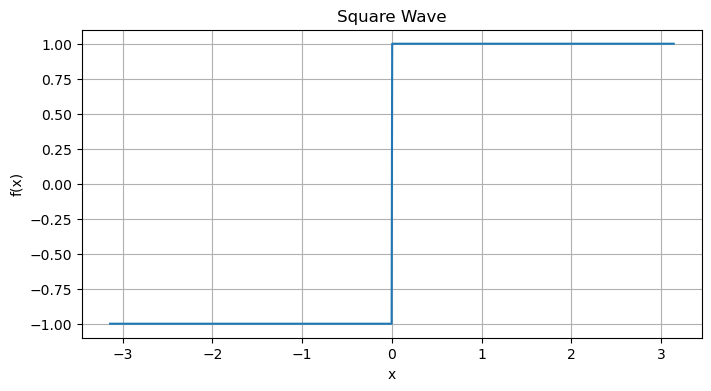

In [6]:
#We are going to define the square wave first
x = np.linspace(-np.pi, np.pi, 1000)

# np.where essentially means ff an element is greater than or equal to 0, return 1, otherwise return -1
square_wave = np.where(x >=0, 1, -1)

plt.figure(figsize = (8,4))
plt.plot(x, square_wave)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Square Wave')
plt.grid()
plt.show()


The Fourier series for this square wave is

$$
f(x)
=
\frac{4}{\pi}
\left[
\sin x
+
\frac{1}{3}\sin 3x
+
\frac{1}{5}\sin 5x
+
\cdots
\right].
$$

Only odd sine terms appear.

A finite approximation using \(N\) terms is

$$
S_N(x)
=
\frac{4}{\pi}
\sum_{n=0}^{N-1}
\frac{\sin[(2n+1)x]}{2n+1}.
$$

In [9]:
def square_fourier(x,N):
    total = np.zeros_like(x)  #this creates and array to be filled

    for n in range(N):    #here is our sum
        harmonic = 2*n +1
        total += np.sin(harmonic*x) / harmonic
    return(4/np.pi)*total

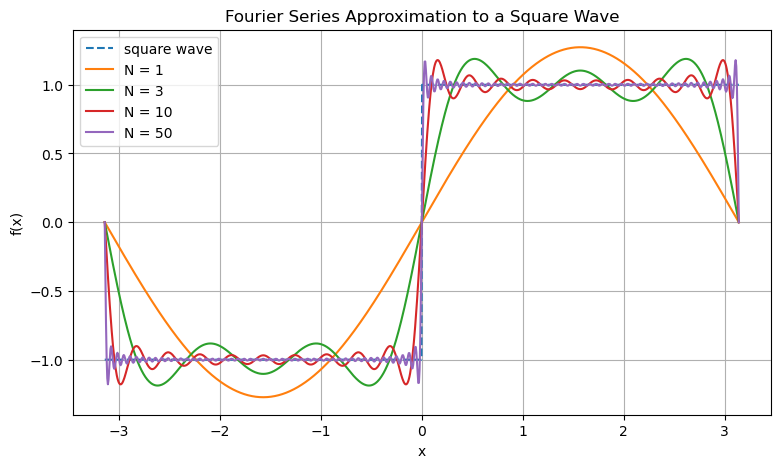

In [12]:
x = np.linspace(-np.pi, np.pi, 1000)

square_wave = np.where(x >=0, 1, -1)

plt.figure(figsize=(9,5))

plt.plot(x, square_wave, '--', label='square wave')

for N in [1, 3, 10, 50]:
    approximation = square_fourier(x,N)
    plt.plot(x, approximation, label=f"N = {N}")

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Series Approximation to a Square Wave')
plt.legend()
plt.grid()
plt.show()

The square wave is built from odd terms: $\sin(x)$, $\frac{1}{3}\sin(3x)$,$\frac{1}{5}\sin(5x), \cdots $.

Let's plot some of them

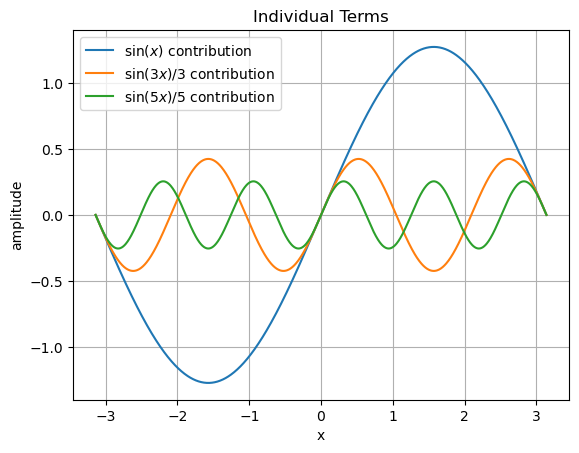

In [14]:
x = np.linspace(-np.pi, np.pi, 1000)

t1 = (4/np.pi) * np.sin(x)
t3 = (4/np.pi) * np.sin(3*x)/3
t5 = (4/np.pi) * np.sin(5*x) / 5
plt.figure()

plt.plot(x, t1, label=r"$\sin(x)$ contribution")
plt.plot(x, t3, label=r"$\sin(3x)/3$ contribution")
plt.plot(x, t5, label=r"$\sin(5x)/5$ contribution")

plt.xlabel('x')
plt.ylabel('amplitude')
plt.title('Individual Terms')
plt.legend()
plt.grid()
plt.show()

Adding the terms together gets us the following:

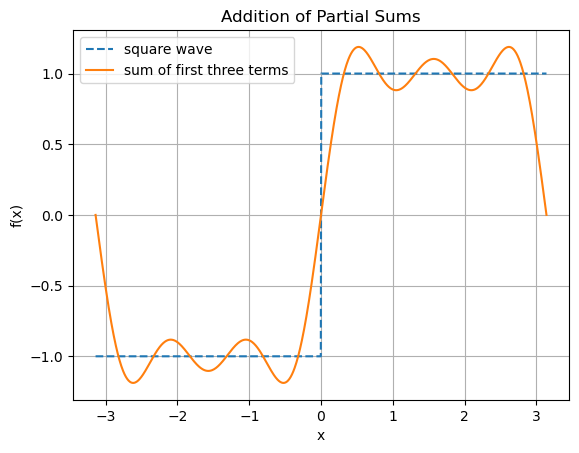

In [19]:
partial_sum = t1 + t3 + t5
plt.figure()
plt.plot(x, square_wave, '--', label='square wave')
plt.plot(x, partial_sum, label ='sum of first three terms')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Addition of Partial Sums')
plt.legend()
plt.grid()
plt.show()

The overshoot on either side of a 'jump' does not disappear if we add more terms. This is called the Gibbs Phenomenom. Let's zoom in at x = 0.

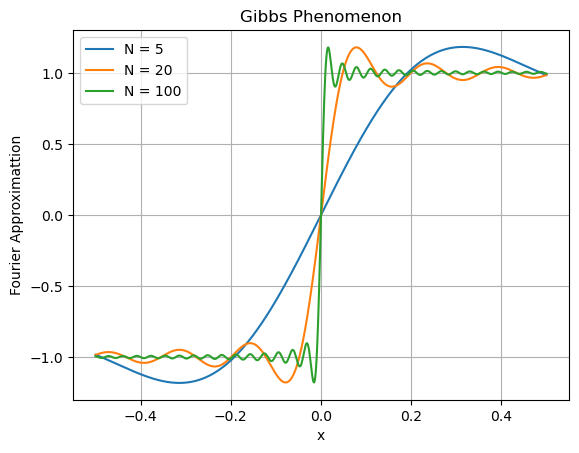

In [24]:
x = np.linspace(-0.5, 0.5, 2000)
plt.figure()

for N in [5, 20, 100]:
    approximation = square_fourier(x,N)
    plt.plot(x, approximation, label=f"N = {N}")


plt.xlabel('x')
plt.ylabel('Fourier Approximattion')
plt.title('Gibbs Phenomenon')
plt.legend()
plt.grid()

plt.show()

# General Fourier Series:
For a general \(2\pi\)-periodic function,

$$
f(x)
=
\frac{a_0}{2}
+
\sum_{n=1}^{N}
\left[
a_n\cos(nx)
+
b_n\sin(nx)
\right].
$$

The coefficients are
$$
a_n
=
\frac{1}{\pi}
\int_{-\pi}^{\pi}
f(x)\cos(nx)\,dx,
$$

$$
b_n
=
\frac{1}{\pi}
\int_{-\pi}^{\pi}
f(x)\sin(nx)\,dx.
$$

We will approximate these integrals numerically using the trapezoid rule.

Take:
$$
f(x)=x
$$

on
$$
-\pi < x < \pi.
$$

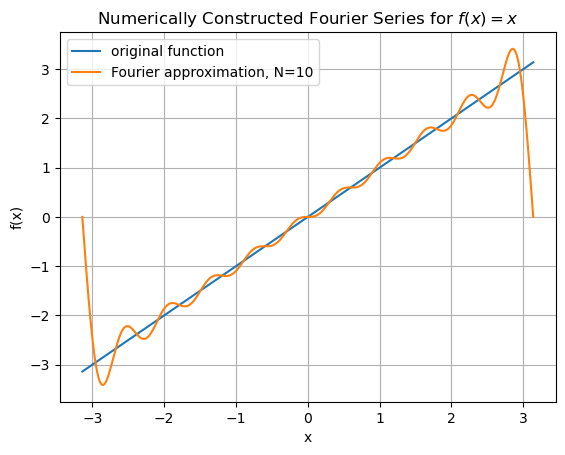

In [31]:
x = np.linspace(-np.pi, np.pi, 1000)
f = x #here is our function

#nuemrically computing fourier coeffficients
N = 10

a = np.zeros(N+1)
b = np.zeros(N+1)

a[0] = (1/np.pi) * np.trapezoid(f,x)  #here np.trapezoid is integrating using the trapezoidal rule
for n in range(1, N+1):
    a[n] = (1/np.pi) * np.trapezoid(f * np.cos(n*x), x)
    b[n] = (1/np.pi) * np.trapezoid(f * np.sin(n*x), x)

fourier = 0.5 * a[0] * np.ones_like(x)

#calculating a_n and b_n
for n in range(1, N+1):
    fourier += a[n]*np.cos(n*x) + b[n]*np.sin(n*x)

#plot stuff
plt.figure()
plt.plot(x, f, label="original function")
plt.plot(x, fourier, label=f"Fourier approximation, N={N}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Numerically Constructed Fourier Series for $f(x)=x$")
plt.legend()
plt.grid()
plt.show()

# Time Domain to Frequency Domain

Let's imagine a physical signal with two frequencies:
$$x(t) = 2\sin(2\pi f_1t) + 0.8\sin(2 \pi f_2t) $$
With $f_1 = 5 $ Hz and $f_2 = 12 $ Hz

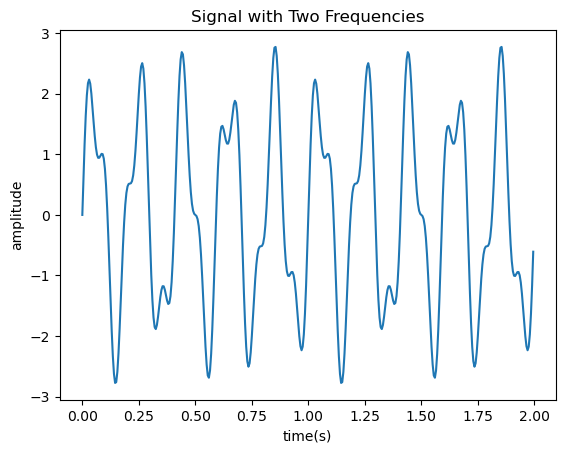

In [35]:
f1 = 5
f2 = 12

sampling_rate = 200

t = np.arange(0, 2, 1/sampling_rate)
signal = (2.0 * np.sin(2*np.pi*f1*t) + 0.8*np.sin(2*np.pi*f2*t))

plt.figure()
plt.plot(t, signal)
plt.xlabel('time(s)')
plt.ylabel('amplitude')
plt.title('Signal with Two Frequencies')
plt.show()

# Fast Fourier Transform
We will be using the numpy function
https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

In [37]:
fft_values = np.fft.fft(signal) #returns an array of complex numbers

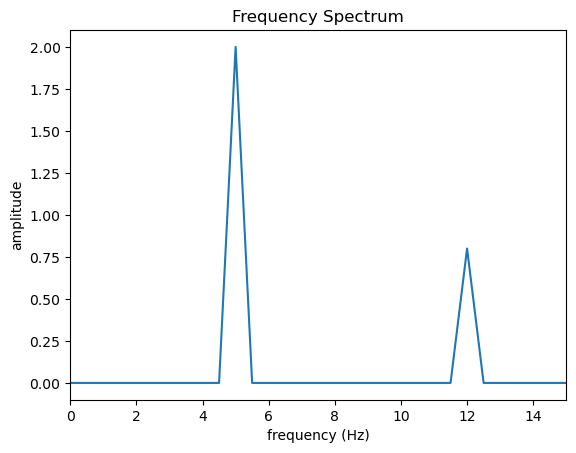

In [44]:
#getting the frequencies
frequencies = np.fft.fftfreq(len(signal),d=1/sampling_rate) #generates the exact 
                                                           #physical frequency values

positive = frequencies >= 0
freq_positive = frequencies[positive]
fft_positive = fft_values[positive]

amplitude = 2 * np.abs(fft_positive)/len(signal)

plt.figure()
plt.plot(freq_positive, amplitude)
plt.xlim(0, 15)
plt.xlabel('frequency (Hz)')
plt.ylabel('amplitude')
plt.title('Frequency Spectrum')
plt.show()

Adding noise to signal:

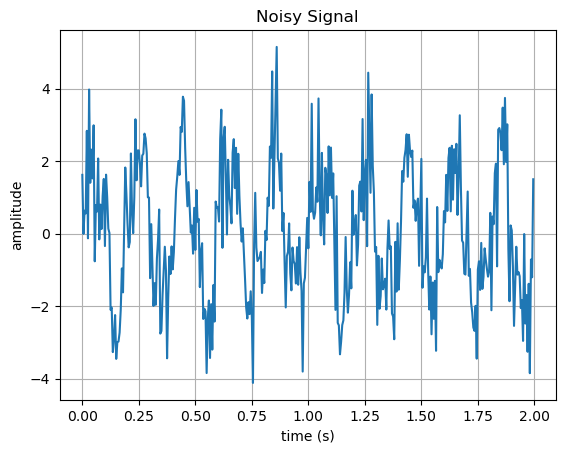

In [46]:
np.random.seed(1) #random number generating set to a specific seed. Try different ones

noise = np.random.normal(
    0,
    1.0,
    len(t)
)

noisy_signal = signal + noise

plt.figure()

plt.plot(t, noisy_signal)

plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("Noisy Signal")
plt.grid()
plt.show()

Let's do a FFT on the signal above.

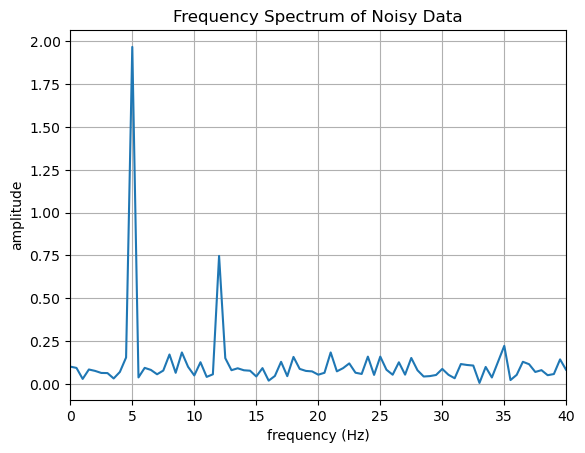

In [47]:
fft_noisy = np.fft.fft(noisy_signal)
fft_noisy_positive = fft_noisy[positive]

amplitude_noisy = (
    2 * np.abs(fft_noisy_positive)
    / len(noisy_signal)
)

plt.figure()
plt.plot(freq_positive, amplitude_noisy)
plt.xlim(0, 40)
plt.xlabel('frequency (Hz)')
plt.ylabel('amplitude')
plt.title('Frequency Spectrum of Noisy Data')
plt.grid()
plt.show()

Filtering Frequency:
Let's remove high-frequency noise. In this case anything above 20 hz

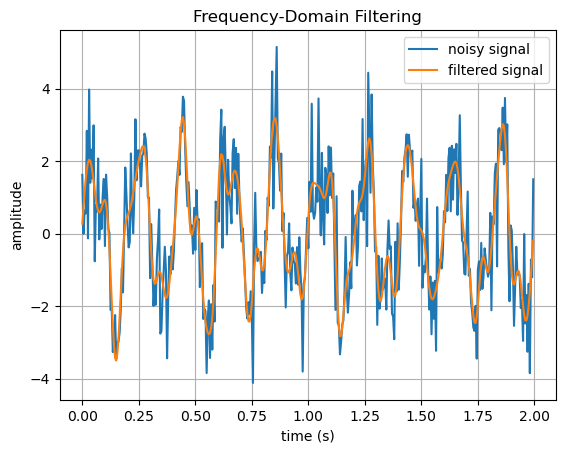

In [54]:
#fft on noisy signal
fft_filtered = np.fft.fft(noisy_signal)

frequencies = np.fft.fftfreq(
    len(noisy_signal),
    d=1/sampling_rate
)

#removing frequencies above 20 Hz
cutoff = 20  

fft_filtered[np.abs(frequencies) > cutoff] = 0

#transforming to time domain
filtered_signal = np.fft.ifft(fft_filtered).real  #iift is the inverse fast fourier transform
                                        
plt.figure()
plt.plot(t, noisy_signal, label="noisy signal")
plt.plot(t, filtered_signal, label="filtered signal")
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.title('Frequency-Domain Filtering')
plt.legend()
plt.grid()
plt.show()

Comparing the original, noisy, and filtered signals

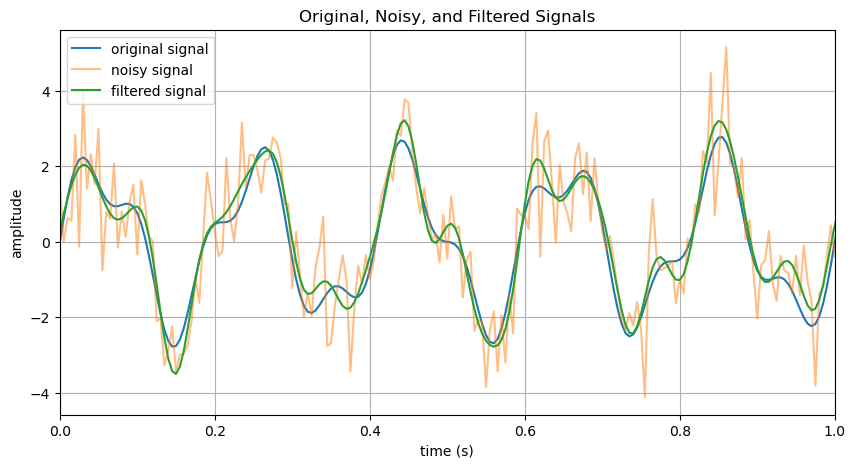

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(t, signal, label="original signal")
plt.plot(t, noisy_signal, alpha=0.5, label="noisy signal")
plt.plot(t, filtered_signal, label="filtered signal")

plt.xlim(0, 1)

plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("Original, Noisy, and Filtered Signals")
plt.legend()
plt.grid(True)
plt.show()

Try messing around with different cutoff values

# Oscillator 
Suppose an experimental oscillator contains a dominant frequency and a smaller higher harmonic:

$
x(t)
=
A_1\cos(2\pi f_1 t)
+
A_2\cos(2\pi f_2 t+\phi).
$

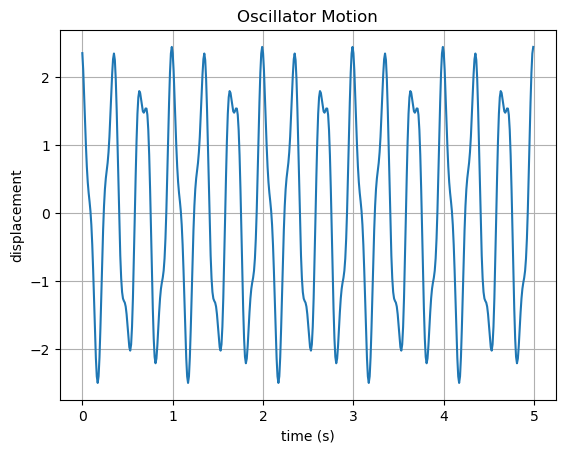

In [57]:
A1 = 2.0
A2 = 0.5

f1 = 3.0
f2 = 8.0

phi = np.pi/4

sampling_rate = 100
t = np.arange(0, 5, 1/sampling_rate)

x = (
    A1 * np.cos(2*np.pi*f1*t)
    +
    A2 * np.cos(2*np.pi*f2*t + phi)
)

plt.figure()
plt.plot(t, x)
plt.xlabel('time (s)')
plt.ylabel('displacement')
plt.title('Oscillator Motion')
plt.grid()
plt.show()

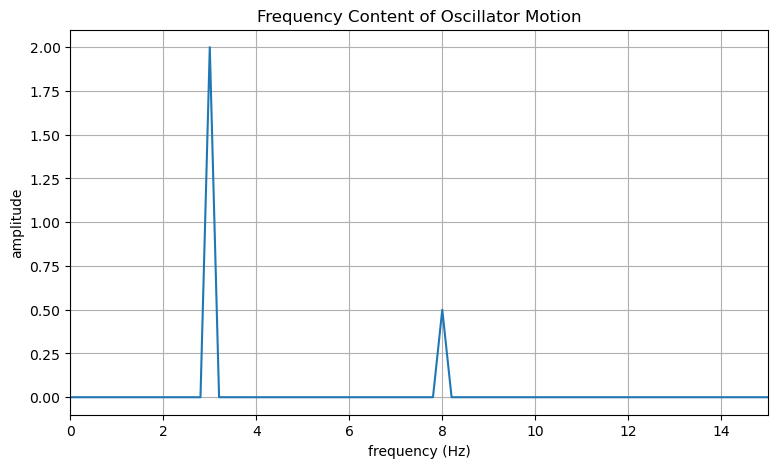

In [60]:
#computing fft
fft_motion = np.fft.fft(x)

freq_motion = np.fft.fftfreq(
    len(x),
    d=1/sampling_rate
)

positive = freq_motion >= 0

amplitude_motion = (
    2
    * np.abs(fft_motion[positive])
    / len(x)
)

plt.figure(figsize=(9, 5))

plt.plot(freq_motion[positive], amplitude_motion)

plt.xlim(0, 15)

plt.xlabel('frequency (Hz)')
plt.ylabel('amplitude')
plt.title('Frequency Content of Oscillator Motion')
plt.grid()
plt.show()